Breast Cancer Stage Progression Notebook

Goal:
Focus on breast cancer only, cancer-related claims only, and compare how costs and cost drivers change across Stage I, II, III, and IV.

Main questions:
1. How do cost levels differ across stages?
2. How do costs change around staging and across simple time windows?
3. Which drugs / HCPCS / procedures / providers drive spending at each stage?
4. Which drivers are stage-specific versus shared across stages?
5. Which patient-level features matter most for identifying high-cost patients within breast cancer?

I. Imports and Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


/opt/anaconda3/lib/python3.12/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.12/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [3]:
claims = pd.read_csv("cleaned_claims.csv")
staging = pd.read_csv("cleaned_staging.csv")

df = claims.merge(staging, on="member_number", how="inner")
df["days_from_stage"] = df["days_since_earliest_dt"] - df["most_recent_stage_date"]

# breast + cancer-related only
breast = df[
    (df["cancer_type"] == "breast") &
    (df["is_cancer_related"] == True)
].copy()

stage_order = ["I", "II", "III", "IV"]
breast = breast[breast["final_stage_simple"].isin(stage_order)].copy()


In [4]:
print("Breast cancer-related claims:", breast.shape)
print("Unique breast patients:", breast["member_number"].nunique())
print("Patients by stage:")
print(
    breast[["member_number", "final_stage_simple"]]
    .drop_duplicates()["final_stage_simple"]
    .value_counts()
    .reindex(stage_order)
)

Breast cancer-related claims: (530758, 30)
Unique breast patients: 2041
Patients by stage:
final_stage_simple
I      1416
II      375
III     140
IV      110
Name: count, dtype: int64


- Breast cancer dominates the cohort, with 2,041 unique breast patients and over 530K cancer-related claims.
- The population is heavily concentrated in earlier stages, especially Stage I (1,416 patients).
- Later-stage groups are much smaller: Stage III (140) and Stage IV (110), so those results may be more variable.

II. Simple Time Windows

In [6]:
breast["stage_time_window"] = np.select(
    [
        breast["days_from_stage"] < 0,
        breast["days_from_stage"].between(0, 90),
        breast["days_from_stage"] > 90,
    ],
    ["pre_stage", "0_to_90", "post_90"],
    default=np.nan,
)

In [7]:
breast["phase"] = np.select(
    [
        breast["days_since_earliest_dt"] <= 180,
        breast["days_since_earliest_dt"].between(181, 1000),
        breast["days_since_earliest_dt"] > 1000,
    ],
    ["initial", "continuing", "late"],
    default=np.nan,
)

III. Stage-Level Patient Summary

In [8]:
def safe_mean(x):
    if len(x) == 0:
        return 0
    return x.mean()


In [9]:
def clean_value(x):
    x = x.astype(str).str.strip()
    x = x.replace("", np.nan)
    x = x.replace("nan", np.nan)
    x = x.replace("NAN", np.nan)
    return x

In [11]:
def build_patient_table(df):
    rows = []

    for pid, g in df.groupby("member_number"):
        g = g.sort_values("days_since_earliest_dt")

        initial = g[g["phase"] == "initial"]
        continuing = g[g["phase"] == "continuing"]
        late = g[g["phase"] == "late"]

        rows.append({
            "member_number": pid,
            "stage": g["final_stage_simple"].iloc[0],
            "time_to_stage": g["most_recent_stage_date"].iloc[0],
            "followup_days": g["days_since_earliest_dt"].max(),
            "n_claims": len(g),
            "n_drugs": clean_value(g["DRUG_NM"]).dropna().nunique(),
            "n_hcpcs": clean_value(g["HCPCS"]).dropna().nunique(),
            "n_proc": clean_value(g["PROC_DESC"]).dropna().nunique(),
            "n_providers": clean_value(g["provider_number"]).dropna().nunique(),
            "total_cost": g["c_allowed"].sum(),
            "mean_claim_cost": g["c_allowed"].mean(),
            "initial_cost": initial["c_allowed"].sum(),
            "continuing_cost": continuing["c_allowed"].sum(),
            "late_cost": late["c_allowed"].sum(),
            "initial_mean_cost": safe_mean(initial["c_allowed"]),
            "continuing_mean_cost": safe_mean(continuing["c_allowed"]),
            "late_mean_cost": safe_mean(late["c_allowed"]),
        })

    out = pd.DataFrame(rows)
    out["initial_share"] = out["initial_cost"] / out["total_cost"].replace(0, np.nan)
    out["continuing_share"] = out["continuing_cost"] / out["total_cost"].replace(0, np.nan)
    out["late_share"] = out["late_cost"] / out["total_cost"].replace(0, np.nan)

    return out.fillna(0)


In [12]:
patient = build_patient_table(breast)
patient.head()


,member_number,stage,time_to_stage,followup_days,n_claims,n_drugs,n_hcpcs,n_proc,n_providers,total_cost,mean_claim_cost,initial_cost,continuing_cost,late_cost,initial_mean_cost,continuing_mean_cost,late_mean_cost,initial_share,continuing_share,late_share
0,A001,II,203.0,0,4,0,4,4,2,1005.000000,251.250000,1005.000000,0.000000,0.000000,251.250000,0.000000,0.000000,1.000000,0.000000,0.000000
1,A002,I,110.0,1247,791,3,174,154,23,387856.652150,490.337108,69500.220000,188107.101465,130249.330686,423.781829,445.751425,635.362589,0.179190,0.484991,0.335818
2,A003,I,755.0,1391,289,0,104,97,22,130598.770000,451.898858,87017.960000,43106.440000,474.370000,591.958912,319.306963,67.767143,0.666300,0.330068,0.003632
3,A004,II,-2843.0,111,8,0,7,7,4,696.728062,87.091008,696.728062,0.000000,0.000000,87.091008,0.000000,0.000000,1.000000,0.000000,0.000000
4,A006,I,53.0,788,106,0,52,45,9,12843.868279,121.168569,10787.773127,2056.095152,0.000000,161.011539,52.720389,0.000000,0.839916,0.160084,0.000000


In [13]:
stage_patient_summary = (
    patient.groupby("stage")
    .agg(
        n_patients=("member_number", "nunique"),
        mean_total_cost=("total_cost", "mean"),
        median_total_cost=("total_cost", "median"),
        mean_claim_cost=("mean_claim_cost", "mean"),
        mean_n_claims=("n_claims", "mean"),
        mean_time_to_stage=("time_to_stage", "mean"),
        mean_followup=("followup_days", "mean"),
        mean_initial_share=("initial_share", "mean"),
        mean_continuing_share=("continuing_share", "mean"),
        mean_late_share=("late_share", "mean"),
    )
    .reindex(stage_order)
)

stage_patient_summary


,n_patients,mean_total_cost,median_total_cost,mean_claim_cost,mean_n_claims,mean_time_to_stage,mean_followup,mean_initial_share,mean_continuing_share,mean_late_share
stage,,,,,,,,,,
I,1416,64451.747264,35465.020393,259.865873,200.631356,116.771893,1416.451977,0.656556,0.230211,0.113233
II,375,120551.812937,65776.856865,293.749400,331.906667,153.826667,1447.245333,0.558113,0.331625,0.110262
III,140,183936.876189,112800.517744,353.494164,437.921429,288.392857,1511.828571,0.476250,0.375123,0.141484
IV,110,349672.780242,118844.601867,513.447751,553.545455,518.263636,1506.418182,0.318224,0.397191,0.275494


- Costs rise sharply with stage: average total cost increases from about $64K in Stage I to about $350K in Stage IV.
- Later stages also have more claims and more expensive claims, so the increase is driven by both volume and intensity.
- As stage increases, spending becomes less front-loaded: Stage I is concentrated more in the initial phase, while Stages III–IV have a larger share in continuing and late-phase care.
- Patients in later stages also tend to be staged later and followed longer, which fits a more complex, prolonged treatment path.

IV. Overall Stage Cost Comparison

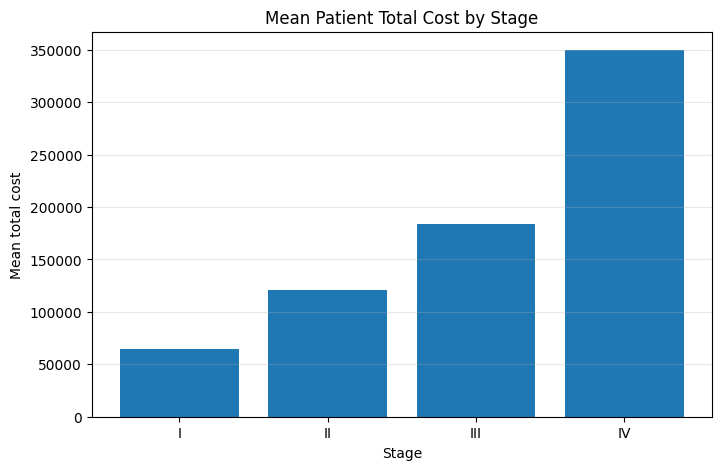

In [15]:
plt.figure(figsize=(8, 5))
plt.bar(stage_patient_summary.index, stage_patient_summary["mean_total_cost"])
plt.title("Mean Patient Total Cost by Stage")
plt.xlabel("Stage")
plt.ylabel("Mean total cost")
plt.grid(axis="y", alpha=0.3)
plt.show()

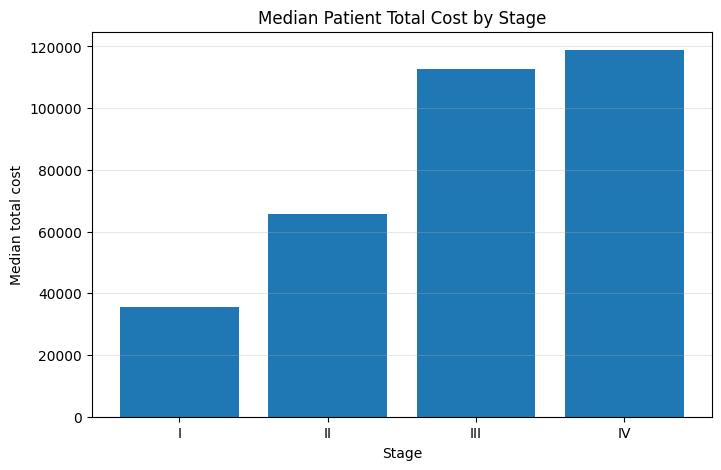

In [16]:
plt.figure(figsize=(8, 5))
plt.bar(stage_patient_summary.index, stage_patient_summary["median_total_cost"])
plt.title("Median Patient Total Cost by Stage")
plt.xlabel("Stage")
plt.ylabel("Median total cost")
plt.grid(axis="y", alpha=0.3)
plt.show()

- Costs increase steadily from Stage I to Stage IV.
- The gap is especially large in the mean, showing that later stages include a subset of very high-cost patients.
- The median also rises a lot, so this is not just a few outliers — the typical patient is more expensive at later stages too.

V. Cost Trajectories by Stage

In [17]:
stage_daily = (
    breast.groupby(["days_since_earliest_dt", "final_stage_simple"])
    .agg(
        total_cost=("c_allowed", "sum"),
        n_patients=("member_number", "nunique")
    )
    .reset_index()
)

stage_daily["cost_per_patient"] = stage_daily["total_cost"] / stage_daily["n_patients"]

pivot = stage_daily.pivot(
    index="days_since_earliest_dt",
    columns="final_stage_simple",
    values="cost_per_patient"
)

pivot = pivot[pivot.index <= 2000]
rolling = pivot.rolling(30, min_periods=1).mean()

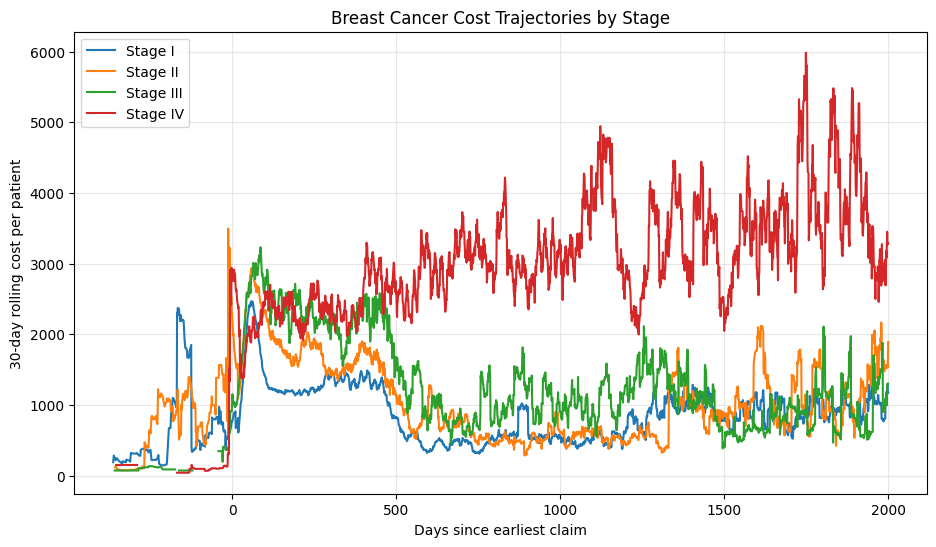

In [18]:
plt.figure(figsize=(11, 6))
for s in stage_order:
    if s in rolling.columns:
        plt.plot(rolling.index, rolling[s], label=f"Stage {s}")
plt.title("Breast Cancer Cost Trajectories by Stage")
plt.xlabel("Days since earliest claim")
plt.ylabel("30-day rolling cost per patient")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Stage IV separates clearly from the rest, with much higher and more sustained costs across the full timeline.
- Stages I–III all show an early treatment spike, but later stages have larger spikes and more volatility over time.
- Stage I stays lowest and most stable overall, while Stage III starts to look much more uneven, suggesting more complex treatment paths.

VI. Cost Around Staging by Stage

In [19]:
stage_around = (
    breast.groupby(["days_from_stage", "final_stage_simple"])
    .agg(
        total_cost=("c_allowed", "sum"),
        n_patients=("member_number", "nunique")
    )
    .reset_index()
)

stage_around["cost_per_patient"] = stage_around["total_cost"] / stage_around["n_patients"]

pivot = stage_around.pivot(
    index="days_from_stage",
    columns="final_stage_simple",
    values="cost_per_patient"
)

pivot = pivot.sort_index()
rolling = pivot.rolling(30, min_periods=1).mean()


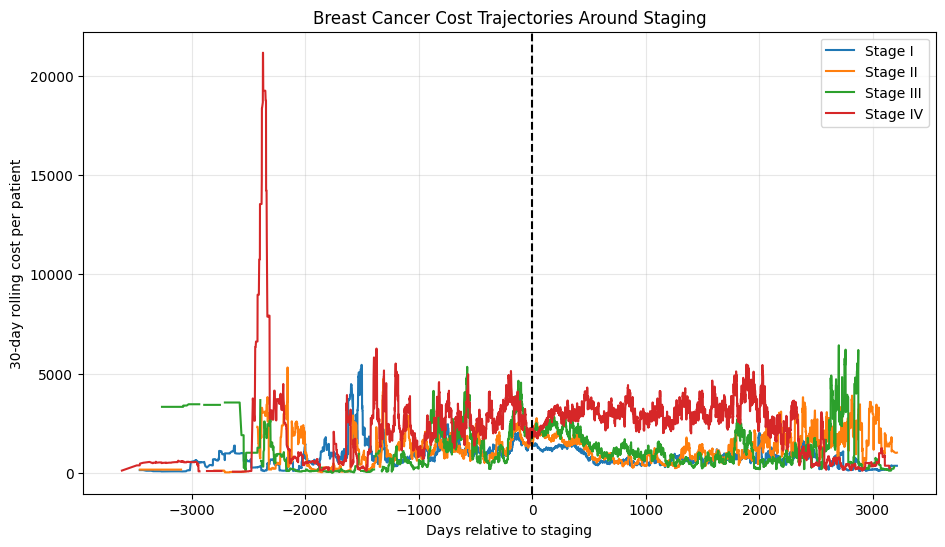

In [20]:
plt.figure(figsize=(11, 6))
for s in stage_order:
    if s in rolling.columns:
        plt.plot(rolling.index, rolling[s], label=f"Stage {s}")
plt.axvline(0, color="black", linestyle="--")
plt.title("Breast Cancer Cost Trajectories Around Staging")
plt.xlabel("Days relative to staging")
plt.ylabel("30-day rolling cost per patient")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

- Staging is a major cost inflection point: costs generally rise around the staging date, then stay elevated afterward rather than quickly dropping back down.
- Stage IV stands out most clearly, with much higher costs both around staging and throughout the post-staging period.
- Earlier stages also show activity around staging, but the cost surge is smaller and less sustained than in later stages.

VII. Simple Driver Summaries by Stage and Window

In [21]:
def summarize_driver(df, col, by_window=False, top_n=10):
    temp = df.copy()
    temp[col] = clean_value(temp[col])
    temp = temp[temp[col].notna()].copy()

    group_cols = ["final_stage_simple", col]
    total_cols = ["final_stage_simple"]

    if by_window:
        temp = temp[temp["stage_time_window"].notna()].copy()
        group_cols = ["final_stage_simple", "stage_time_window", col]
        total_cols = ["final_stage_simple", "stage_time_window"]

    out = (
        temp.groupby(group_cols)
        .agg(
            n_claims=("member_number", "size"),
            n_patients=("member_number", "nunique"),
            total_cost=("c_allowed", "sum"),
            mean_cost=("c_allowed", "mean"),
        )
        .reset_index()
    )

    totals = (
        temp.groupby(total_cols)["c_allowed"]
        .sum()
        .rename("group_total_cost")
        .reset_index()
    )

    out = out.merge(totals, on=total_cols, how="left")
    out["cost_share"] = out["total_cost"] / out["group_total_cost"]
    out["rank"] = out.groupby(total_cols)["total_cost"].rank(method="first", ascending=False)

    out = out[out["rank"] <= top_n].copy()
    return out.sort_values(total_cols + ["rank"]).reset_index(drop=True)


In [22]:
# top drivers by stage
stage_drugs = summarize_driver(breast, "DRUG_NM", by_window=False, top_n=10)
stage_hcpcs = summarize_driver(breast, "HCPCS", by_window=False, top_n=10)
stage_proc = summarize_driver(breast, "PROC_DESC", by_window=False, top_n=10)
stage_provider = summarize_driver(breast, "provider_number", by_window=False, top_n=10)


In [23]:
# time-aware top drivers by stage
window_drugs = summarize_driver(breast, "DRUG_NM", by_window=True, top_n=10)
window_hcpcs = summarize_driver(breast, "HCPCS", by_window=True, top_n=10)
window_proc = summarize_driver(breast, "PROC_DESC", by_window=True, top_n=10)
window_provider = summarize_driver(breast, "provider_number", by_window=True, top_n=10)

In [24]:
def compact_top_by_stage(summary_df, col, top_n=3):
    out = summary_df[summary_df["rank"] <= top_n].copy()
    compact = out.pivot(index="rank", columns="final_stage_simple", values=col)
    compact = compact.reindex(columns=stage_order)
    compact.index = [f"Top {int(i)}" for i in compact.index]
    return compact

In [25]:
print("Top 3 drugs by stage")
display(compact_top_by_stage(stage_drugs, "DRUG_NM", top_n=3))

print("Top 3 HCPCS by stage")
display(compact_top_by_stage(stage_hcpcs, "HCPCS", top_n=3))

print("Top 3 procedures by stage")
display(compact_top_by_stage(stage_proc, "PROC_DESC", top_n=3))

print("Top 3 providers by stage")
display(compact_top_by_stage(stage_provider, "provider_number", top_n=3))


Top 3 drugs by stage


final_stage_simple,I,II,III,IV
Top 1,ENBREL,IBRANCE,IBRANCE,IBRANCE
Top 2,JAKAFI,VERZENIO,VERZENIO,NERLYNX
Top 3,VERZENIO,EXEMESTANE,PIQRAY,VERZENIO


Top 3 HCPCS by stage


final_stage_simple,I,II,III,IV
Top 1,J9355,J9306,J9271,J9355
Top 2,J9354,J9271,J9306,J9306
Top 3,J9306,J9355,J9355,J0897


Top 3 procedures by stage


final_stage_simple,I,II,III,IV
Top 1,TRASTUZUMAB INJECTION,"INJECTION, PERTUZUMAB, 1 MG",INJ PEMBROLIZUMAB,TRASTUZUMAB INJECTION
Top 2,"INJ, ADO-TRASTUZUMAB EMT 1MG",INJ PEMBROLIZUMAB,"INJECTION, PERTUZUMAB, 1 MG","INJECTION, PERTUZUMAB, 1 MG"
Top 3,"INJECTION, PERTUZUMAB, 1 MG",TRASTUZUMAB INJECTION,TRASTUZUMAB INJECTION,DENOSUMAB INJECTION


Top 3 providers by stage


final_stage_simple,I,II,III,IV
Top 1,2244.0,2244.0,2244.0,2244.0
Top 2,2236.0,2236.0,2236.0,2236.0
Top 3,2223.0,2223.0,2015.0,2254.0


- There is a mix of shared and stage-specific drivers: some therapies show up across multiple stages, while others become more prominent only in later disease.
- IBRANCE appears across Stages II–IV, suggesting it is a consistent driver once disease is more advanced, while ENBREL/JAKAFI showing up in Stage I may reflect noise or non-core treatment mix worth validating.
- Procedure and HCPCS rankings suggest later stages are increasingly tied to targeted infusion/injection-based treatment patterns, especially in Stage III–IV.
- The top providers are highly concentrated and mostly repeat across stages, which suggests a relatively small set of providers may account for a large share of breast cancer treatment costs.

In [42]:
stage_order = ["I", "II", "III", "IV"]

def clean_value(x):
    x = x.astype(str).str.strip()
    x = x.replace("", np.nan)
    x = x.replace("nan", np.nan)
    x = x.replace("NAN", np.nan)
    return x

def top_driver_cost_share(df, col, top_n=3):
    temp = df.copy()
    temp[col] = clean_value(temp[col])
    temp = temp[temp["final_stage_simple"].isin(stage_order)].copy()

    # total stage cost across all claims in that stage
    stage_totals = (
        temp.groupby("final_stage_simple")["c_allowed"]
        .sum()
        .rename("stage_total_cost")
        .reset_index()
    )

    # only rows where the driver field is present
    driver_rows = temp[temp[col].notna()].copy()

    # summarize driver cost within each stage
    out = (
        driver_rows.groupby(["final_stage_simple", col])
        .agg(
            n_claims=("member_number", "size"),
            n_patients=("member_number", "nunique"),
            total_cost=("c_allowed", "sum"),
            mean_cost=("c_allowed", "mean"),
        )
        .reset_index()
    )

    out = out.merge(stage_totals, on="final_stage_simple", how="left")
    out["cost_share_of_stage"] = out["total_cost"] / out["stage_total_cost"]

    out["rank"] = (
        out.groupby("final_stage_simple")["total_cost"]
        .rank(method="first", ascending=False)
    )

    out = (
        out[out["rank"] <= top_n]
        .sort_values(["final_stage_simple", "rank"])
        .reset_index(drop=True)
    )

    return out

def top_n_total_share(summary_df):
    # sum of the top-N shares within each stage
    return (
        summary_df.groupby("final_stage_simple")
        .agg(
            top_n_total_cost=("total_cost", "sum"),
            stage_total_cost=("stage_total_cost", "first")
        )
        .assign(top_n_share=lambda x: x["top_n_total_cost"] / x["stage_total_cost"])
        .reset_index()
        .sort_values("final_stage_simple")
    )


In [43]:
drug_share = top_driver_cost_share(breast, "DRUG_NM", top_n=3)
hcpcs_share = top_driver_cost_share(breast, "HCPCS", top_n=3)
proc_share = top_driver_cost_share(breast, "PROC_DESC", top_n=3)
provider_share = top_driver_cost_share(breast, "provider_number", top_n=3)

In [44]:
print("Top 3 drugs by stage with cost share")
display(drug_share[[
    "final_stage_simple", "rank", "DRUG_NM",
    "total_cost", "stage_total_cost", "cost_share_of_stage",
    "n_claims", "n_patients"
]])

print("Top 3 HCPCS by stage with cost share")
display(hcpcs_share[[
    "final_stage_simple", "rank", "HCPCS",
    "total_cost", "stage_total_cost", "cost_share_of_stage",
    "n_claims", "n_patients"
]])

print("Top 3 procedures by stage with cost share")
display(proc_share[[
    "final_stage_simple", "rank", "PROC_DESC",
    "total_cost", "stage_total_cost", "cost_share_of_stage",
    "n_claims", "n_patients"
]])

print("Top 3 providers by stage with cost share")
display(provider_share[[
    "final_stage_simple", "rank", "provider_number",
    "total_cost", "stage_total_cost", "cost_share_of_stage",
    "n_claims", "n_patients"
]])

Top 3 drugs by stage with cost share


,final_stage_simple,rank,DRUG_NM,total_cost,stage_total_cost,cost_share_of_stage,n_claims,n_patients
0,I,1.0,ENBREL,1.529027e+05,9.126367e+07,0.001675,16,1
1,I,2.0,JAKAFI,1.461173e+05,9.126367e+07,0.001601,9,1
2,I,3.0,VERZENIO,9.736201e+04,9.126367e+07,0.001067,7,3
3,II,1.0,IBRANCE,8.734866e+04,4.520693e+07,0.001932,7,1
4,II,2.0,VERZENIO,5.455296e+04,4.520693e+07,0.001207,4,1
5,II,3.0,EXEMESTANE,2.884671e+04,4.520693e+07,0.000638,138,12
6,III,1.0,IBRANCE,6.551474e+05,2.575116e+07,0.025441,61,2
7,III,2.0,VERZENIO,5.830413e+04,2.575116e+07,0.002264,4,2
8,III,3.0,PIQRAY,2.089346e+04,2.575116e+07,0.000811,1,1
9,IV,1.0,IBRANCE,3.044420e+06,3.846401e+07,0.079150,261,12


Top 3 HCPCS by stage with cost share


,final_stage_simple,rank,HCPCS,total_cost,stage_total_cost,cost_share_of_stage,n_claims,n_patients
0,I,1.0,J9355,7.889367e+06,9.126367e+07,0.086446,1029,63
1,I,2.0,J9354,4.944262e+06,9.126367e+07,0.054176,315,19
2,I,3.0,J9306,4.890637e+06,9.126367e+07,0.053588,380,39
3,II,1.0,J9306,5.619239e+06,4.520693e+07,0.124300,405,45
4,II,2.0,J9271,3.966265e+06,4.520693e+07,0.087736,183,28
5,II,3.0,J9355,3.760919e+06,4.520693e+07,0.083193,414,32
6,III,1.0,J9271,5.426266e+06,2.575116e+07,0.210719,214,24
7,III,2.0,J9306,2.411670e+06,2.575116e+07,0.093653,210,19
8,III,3.0,J9355,1.572896e+06,2.575116e+07,0.061081,216,12
9,IV,1.0,J9355,7.025873e+06,3.846401e+07,0.182661,781,20


Top 3 procedures by stage with cost share


,final_stage_simple,rank,PROC_DESC,total_cost,stage_total_cost,cost_share_of_stage,n_claims,n_patients
0,I,1.0,TRASTUZUMAB INJECTION,7.889367e+06,9.126367e+07,0.086446,1029,63
1,I,2.0,"INJ, ADO-TRASTUZUMAB EMT 1MG",4.944262e+06,9.126367e+07,0.054176,315,19
2,I,3.0,"INJECTION, PERTUZUMAB, 1 MG",4.890637e+06,9.126367e+07,0.053588,380,39
3,II,1.0,"INJECTION, PERTUZUMAB, 1 MG",5.619239e+06,4.520693e+07,0.124300,405,45
4,II,2.0,INJ PEMBROLIZUMAB,3.966265e+06,4.520693e+07,0.087736,183,28
5,II,3.0,TRASTUZUMAB INJECTION,3.760919e+06,4.520693e+07,0.083193,414,32
6,III,1.0,INJ PEMBROLIZUMAB,5.426266e+06,2.575116e+07,0.210719,214,24
7,III,2.0,"INJECTION, PERTUZUMAB, 1 MG",2.411670e+06,2.575116e+07,0.093653,210,19
8,III,3.0,TRASTUZUMAB INJECTION,1.572896e+06,2.575116e+07,0.061081,216,12
9,IV,1.0,TRASTUZUMAB INJECTION,7.025873e+06,3.846401e+07,0.182661,781,20


Top 3 providers by stage with cost share


,final_stage_simple,rank,provider_number,total_cost,stage_total_cost,cost_share_of_stage,n_claims,n_patients
0,I,1.0,2244.0,3.574055e+07,9.126367e+07,0.391619,69306,1014
1,I,2.0,2236.0,1.120961e+07,9.126367e+07,0.122827,30261,747
2,I,3.0,2223.0,6.788074e+06,9.126367e+07,0.074379,16532,184
3,II,1.0,2244.0,2.691967e+07,4.520693e+07,0.595477,49428,300
4,II,2.0,2236.0,4.863620e+06,4.520693e+07,0.107586,14145,213
5,II,3.0,2223.0,1.479973e+06,4.520693e+07,0.032738,3781,31
6,III,1.0,2244.0,1.268778e+07,2.575116e+07,0.492707,21428,109
7,III,2.0,2236.0,2.680699e+06,2.575116e+07,0.104100,7276,88
8,III,3.0,2015.0,2.101030e+06,2.575116e+07,0.081590,1429,3
9,IV,1.0,2244.0,2.003779e+07,3.846401e+07,0.520949,20128,81


- Drug-name-coded costs are a small share of total stage spend, especially in Stages I–II; by contrast, Stage IV has more meaningful concentration, with IBRANCE alone accounting for about 8% of total stage cost.
- HCPCS and procedure costs are much more concentrated and informative than drug names. In Stages III–IV, the top 3 HCPCS / procedures account for a large share of spend, pointing to a more defined treatment mix in later stages.
- Provider concentration is very high across all stages. The top provider alone accounts for roughly 39% of Stage I, 60% of Stage II, 49% of Stage III, and 52% of Stage IV cost.

In [45]:
print("Combined share of stage cost explained by top 3 drugs")
display(top_n_total_share(drug_share))

print("Combined share of stage cost explained by top 3 HCPCS")
display(top_n_total_share(hcpcs_share))

print("Combined share of stage cost explained by top 3 procedures")
display(top_n_total_share(proc_share))

print("Combined share of stage cost explained by top 3 providers")
display(top_n_total_share(provider_share))

Combined share of stage cost explained by top 3 drugs


,final_stage_simple,top_n_total_cost,stage_total_cost,top_n_share
0,I,3.963820e+05,9.126367e+07,0.004343
1,II,1.707483e+05,4.520693e+07,0.003777
2,III,7.343450e+05,2.575116e+07,0.028517
3,IV,4.176605e+06,3.846401e+07,0.108585


Combined share of stage cost explained by top 3 HCPCS


,final_stage_simple,top_n_total_cost,stage_total_cost,top_n_share
0,I,1.772427e+07,9.126367e+07,0.194209
1,II,1.334642e+07,4.520693e+07,0.295230
2,III,9.410832e+06,2.575116e+07,0.365453
3,IV,1.647276e+07,3.846401e+07,0.428264


Combined share of stage cost explained by top 3 procedures


,final_stage_simple,top_n_total_cost,stage_total_cost,top_n_share
0,I,1.772427e+07,9.126367e+07,0.194209
1,II,1.334642e+07,4.520693e+07,0.295230
2,III,9.410832e+06,2.575116e+07,0.365453
3,IV,1.647276e+07,3.846401e+07,0.428264


Combined share of stage cost explained by top 3 providers


,final_stage_simple,top_n_total_cost,stage_total_cost,top_n_share
0,I,5.373823e+07,9.126367e+07,0.588824
1,II,3.326327e+07,4.520693e+07,0.735800
2,III,1.746951e+07,2.575116e+07,0.678397
3,IV,2.493674e+07,3.846401e+07,0.648314


- Drug concentration is low overall: the top 3 drugs explain under 1% of stage cost in Stages I–II, about 3% in Stage III, and about 11% in Stage IV.
- HCPCS and procedures become much more concentrated in later stages: the top 3 account for about 19% of Stage I, 30% of Stage II, 37% of Stage III, and 43% of Stage IV cost.
- Provider concentration is highest of all: the top 3 providers explain about 59% of Stage I, 74% of Stage II, 68% of Stage III, and 65% of Stage IV cost.

IX. Which Drivers Persist Across Stages?

In [26]:
def driver_presence(summary_df, col):
    temp = summary_df[["final_stage_simple", col]].drop_duplicates().copy()
    temp["present"] = 1
    mat = temp.pivot(index=col, columns="final_stage_simple", values="present").fillna(0)
    mat = mat.reindex(columns=stage_order, fill_value=0)
    mat["n_stages_present"] = mat.sum(axis=1)
    return mat.sort_values(["n_stages_present"], ascending=False)

In [27]:
drug_presence = driver_presence(stage_drugs, "DRUG_NM")
hcpcs_presence = driver_presence(stage_hcpcs, "HCPCS")
proc_presence = driver_presence(stage_proc, "PROC_DESC")
provider_presence = driver_presence(stage_provider, "provider_number")

In [28]:
print("Drugs appearing in top-10 across multiple stages")
display(drug_presence.head(20))

Drugs appearing in top-10 across multiple stages


final_stage_simple,I,II,III,IV,n_stages_present
DRUG_NM,,,,,
VERZENIO,1.0,1.0,1.0,1.0,4.0
CAPECITABINE,1.0,1.0,1.0,1.0,4.0
EXEMESTANE,1.0,1.0,1.0,1.0,4.0
ANASTROZOLE,1.0,1.0,1.0,1.0,4.0
IBRANCE,0.0,1.0,1.0,1.0,3.0
LETROZOLE,1.0,0.0,1.0,1.0,3.0
TAMOXIFEN CITRATE,1.0,1.0,0.0,0.0,2.0
LUPRON DEPOT,1.0,1.0,0.0,0.0,2.0
KISQALI,1.0,0.0,0.0,1.0,2.0


- A small set of drugs appears across multiple stages, especially VERZENIO, CAPECITABINE, EXEMESTANE, and ANASTROZOLE, suggesting some treatment drivers persist across the breast cancer pathway.
- IBRANCE becomes more prominent in later stages, appearing in the top 10 for Stages II–IV, which fits the broader pattern of increasing late-stage treatment intensity.
- Several drugs appear in only one stage, which suggests some therapies are more stage-specific and may help explain shifts in treatment mix as disease progresses.

X. Stage-to-Stage Changes

In [29]:
stage_change = stage_patient_summary[["mean_total_cost", "median_total_cost", "mean_claim_cost"]].copy()
stage_change["pct_change_mean_total_cost"] = stage_change["mean_total_cost"].pct_change()
stage_change["pct_change_median_total_cost"] = stage_change["median_total_cost"].pct_change()
stage_change

,mean_total_cost,median_total_cost,mean_claim_cost,pct_change_mean_total_cost,pct_change_median_total_cost
stage,,,,,
I,64451.747264,35465.020393,259.865873,NaN,NaN
II,120551.812937,65776.856865,293.749400,0.870420,0.854697
III,183936.876189,112800.517744,353.494164,0.525791,0.714897
IV,349672.780242,118844.601867,513.447751,0.901048,0.053582


- The biggest cost jump happens early: Stage II is about 87% higher than Stage I on mean total cost, and Stage III is about 53% higher than Stage II.
- Costs continue to rise into Stage IV, but the increase is driven much more by the mean than the median, suggesting a subset of very high-cost Stage IV patients.
- Median costs rise strongly through Stage III, then flatten more from Stage III to IV, which suggests the “typical” patient cost increases less sharply at the highest stage than the average does.

XI. Drug Co-Occurence Within Each Stage (PMI)

In [31]:
def stage_pmi(df, stage, top_k_drugs=20, min_both=5):
    sub = df[df["final_stage_simple"] == stage].copy()
    sub["DRUG_NM"] = clean_value(sub["DRUG_NM"])
    sub = sub[sub["DRUG_NM"].notna()][["member_number", "DRUG_NM"]].drop_duplicates()

    if len(sub) == 0:
        return pd.DataFrame()

    common_drugs = sub["DRUG_NM"].value_counts().head(top_k_drugs).index.tolist()
    sub = sub[sub["DRUG_NM"].isin(common_drugs)].copy()

    patient_sets = sub.groupby("member_number")["DRUG_NM"].apply(set)
    all_patients = len(patient_sets)
    drug_counts = sub["DRUG_NM"].value_counts().to_dict()

    rows = []
    for d1 in common_drugs:
        for d2 in common_drugs:
            if d1 >= d2:
                continue
            both = sum((d1 in s) and (d2 in s) for s in patient_sets)
            if both < min_both:
                continue
            p1 = drug_counts[d1] / all_patients
            p2 = drug_counts[d2] / all_patients
            p12 = both / all_patients
            pmi = np.log(p12 / (p1 * p2))
            rows.append({
                "stage": stage,
                "drug_1": d1,
                "drug_2": d2,
                "n_patients_both": both,
                "pmi": pmi,
            })

    return pd.DataFrame(rows).sort_values(["pmi", "n_patients_both"], ascending=[False, False])


In [32]:
for s in stage_order:
    print(f"\nStage {s} PMI")
    out = stage_pmi(breast, s, top_k_drugs=20, min_both=5)
    display(out.head(10))


Stage I PMI


,stage,drug_1,drug_2,n_patients_both,pmi
14,I,LORAZEPAM,PROCHLORPERAZINE MALEA,5,1.729397
8,I,DEXAMETHASONE,PROCHLORPERAZINE MALEA,43,1.665586
12,I,LIDOCAINE-PRILOCAINE,PROCHLORPERAZINE MALEA,6,1.064421
13,I,LIDOCAINE-PRILOCAINE,TAMOXIFEN CITRATE,5,0.882099
11,I,EXEMESTANE,LETROZOLE,7,0.006231
5,I,ANASTROZOLE,TRAMADOL HCL,5,-0.170660
10,I,EXEMESTANE,TAMOXIFEN CITRATE,6,-0.208545
2,I,ANASTROZOLE,LETROZOLE,24,-0.363032
7,I,LETROZOLE,PROCHLORPERAZINE MALEA,6,-0.455405
4,I,ANASTROZOLE,EXEMESTANE,17,-0.461012



Stage II PMI


,stage,drug_1,drug_2,n_patients_both,pmi
2,II,DEXAMETHASONE,PROCHLORPERAZINE MALEA,34,0.823365
1,II,ANASTROZOLE,DEXAMETHASONE,11,-0.122779
0,II,ANASTROZOLE,PROCHLORPERAZINE MALEA,13,-0.216008



Stage III PMI


,stage,drug_1,drug_2,n_patients_both,pmi
0,III,DEXAMETHASONE,PROCHLORPERAZINE MALEA,17,0.534024
1,III,LORAZEPAM,PROCHLORPERAZINE MALEA,5,0.157546



Stage IV PMI


,stage,drug_1,drug_2,n_patients_both,pmi
0,IV,IBRANCE,LETROZOLE,5,0.489772


- Drug co-occurrence signals are fairly sparse, so these results are better for spotting directional patterns than making strong conclusions.
- Across Stages I–III, the clearest repeated pairing is DEXAMETHASONE + PROCHLORPERAZINE MALEATE, which suggests a recurring supportive-care / symptom-management pattern.
- Stage IV shows a different signal, with IBRANCE + LETROZOLE appearing together, which fits a more advanced, therapy-specific treatment mix.

**Log PMI formula**

$\text{log PMI}(A,B) = \log \left( \frac{P(A,B)}{P(A)\,P(B)} \right)$

Where:
- $P(A,B)$ = proportion of patients who had **both** drugs
- $P(A)$ = proportion of patients who had drug $A$
- $P(B)$ = proportion of patients who had drug $B$

**How to interpret it**
- **Positive log PMI**: the two drugs appear together **more often than expected by chance**
- **Around 0**: they appear together about **as often as expected**
- **Negative log PMI**: they appear together **less often than expected**

**Explanation**
- **Log PMI measures whether a pair of drugs shows up together more often than we would expect based on how common each drug is on its own.**

XII. Predict Whether a Patient is in the Top Cost Quartile

In [33]:
patient["high_cost"] = (patient["total_cost"] >= patient["total_cost"].quantile(0.75)).astype(int)

model_features = [
    "time_to_stage",
    "followup_days",
    "n_claims",
    "n_drugs",
    "n_hcpcs",
    "n_proc",
    "n_providers",
    "mean_claim_cost",
    "initial_share",
    "continuing_share",
    "late_share",
]


In [34]:
X = patient[model_features]
y = patient["high_cost"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

clf = LogisticRegression(max_iter=2000)
clf.fit(X_train_scaled, y_train)

pred = clf.predict(X_test_scaled)
prob = clf.predict_proba(X_test_scaled)[:, 1]

In [35]:
print(classification_report(y_test, pred))
print("AUC:", round(roc_auc_score(y_test, prob), 3))

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       460
           1       0.94      0.88      0.91       153

    accuracy                           0.96       613
   macro avg       0.95      0.93      0.94       613
weighted avg       0.96      0.96      0.96       613

AUC: 0.992


In [36]:
coef_table = pd.DataFrame({
    "feature": model_features,
    "coef": clf.coef_[0],
    "abs_coef": np.abs(clf.coef_[0]),
}).sort_values("abs_coef", ascending=False)

coef_table


,feature,coef,abs_coef
7,mean_claim_cost,3.314499,3.314499
2,n_claims,3.254840,3.254840
4,n_hcpcs,0.644701,0.644701
5,n_proc,0.525273,0.525273
3,n_drugs,-0.260149,0.260149
9,continuing_share,0.232424,0.232424
8,initial_share,-0.228065,0.228065
6,n_providers,0.121967,0.121967
1,followup_days,0.078230,0.078230
10,late_share,0.044833,0.044833


- The high-cost model performs very well overall (AUC = 0.992, 96% accuracy), so these patient-level features do a strong job separating higher-cost from lower-cost patients.
- The biggest drivers are mean claim cost and number of claims, which means high-cost patients are primarily distinguished by having more expensive claims and more claims overall.
- Counts of HCPCS, procedures, and drugs also add signal, but much less than those top two features.

XIII. Simple Ablation

In [37]:
def fit_auc(feature_list):
    X = patient[feature_list]
    y = patient["high_cost"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=2000)
    clf.fit(X_train, y_train)
    prob = clf.predict_proba(X_test)[:, 1]
    return roc_auc_score(y_test, prob)


In [38]:
base_auc = fit_auc(model_features)
rows = []
for f in model_features:
    reduced = [x for x in model_features if x != f]
    auc = fit_auc(reduced)
    rows.append({
        "removed_feature": f,
        "auc_without_feature": auc,
        "auc_drop": base_auc - auc,
    })

In [39]:
ablation = pd.DataFrame(rows).sort_values("auc_drop", ascending=False)
print("Base AUC:", round(base_auc, 3))
ablation

Base AUC: 0.992


,removed_feature,auc_without_feature,auc_drop
7,mean_claim_cost,0.970233,0.021711
2,n_claims,0.982467,0.009477
4,n_hcpcs,0.991887,0.000057
1,followup_days,0.991915,0.000028
9,continuing_share,0.991958,-0.000014
0,time_to_stage,0.991972,-0.000028
6,n_providers,0.992001,-0.000057
8,initial_share,0.992001,-0.000057
10,late_share,0.992001,-0.000057
5,n_proc,0.992043,-0.000099


- he ablation confirms the same story as the coefficient table: mean claim cost is the single most important feature, and number of claims is the clear second.
- Removing either of those causes the biggest drop in AUC, while most other features change performance very little.
- That suggests the model’s predictive power comes mainly from claim intensity and claim volume, not from staging timing or phase-share variables.

XIV. Clustering Trajectories


Stage I cluster summary


,n_patients,mean_time_to_stage,mean_followup,mean_n_claims,mean_initial,mean_continuing,mean_late,mean_total_cost,median_total_cost
cluster,,,,,,,,,
0,612,369.44,2233.47,241.64,274.63,129.40,125.33,54301.84,42217.72
1,99,191.94,1704.14,558.52,535.65,867.38,388.58,372405.18,314271.51
2,705,-113.12,666.82,114.77,262.15,112.38,19.41,30018.20,23355.88



Stage II cluster summary


,n_patients,mean_time_to_stage,mean_followup,mean_n_claims,mean_initial,mean_continuing,mean_late,mean_total_cost,median_total_cost
cluster,,,,,,,,,
0,189,-84.72,701.48,203.27,229.76,130.30,17.44,53447.81,30044.65
1,137,504.39,2504.36,398.08,252.29,180.13,153.69,95768.71,82538.22
2,49,93.78,1368.16,643.06,706.64,849.87,149.19,448673.07,429989.39



Stage III cluster summary


,n_patients,mean_time_to_stage,mean_followup,mean_n_claims,mean_initial,mean_continuing,mean_late,mean_total_cost,median_total_cost
cluster,,,,,,,,,
0,47,751.89,2744.17,489.45,183.19,184.43,202.49,133309.09,107995.18
1,73,36.95,775.74,344.88,242.75,229.32,24.55,101108.22,61406.66
2,20,116.95,1302.55,656.45,925.79,1145.49,125.38,605236.77,559913.61



Stage IV cluster summary


,n_patients,mean_time_to_stage,mean_followup,mean_n_claims,mean_initial,mean_continuing,mean_late,mean_total_cost,median_total_cost
cluster,,,,,,,,,
0,63,159.13,760.38,333.60,359.93,337.68,188.69,150446.70,84828.09
1,16,536.75,2556.12,1288.19,849.72,1408.81,2037.59,1465527.55,1211544.07
2,31,1238.58,2480.77,621.35,192.07,223.64,317.23,178626.56,114553.61


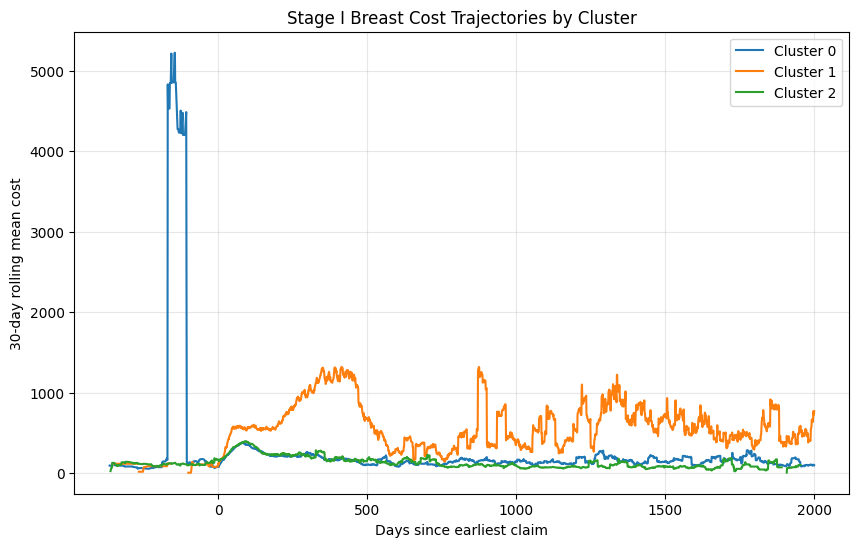

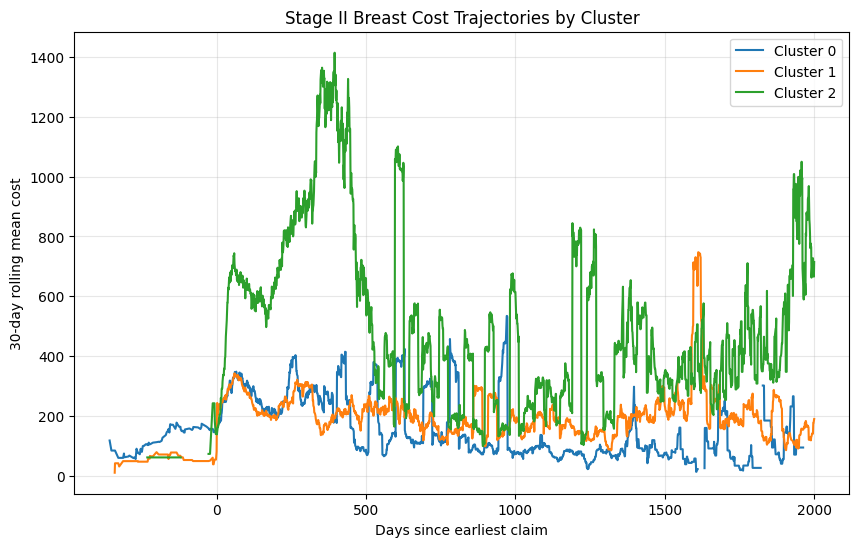

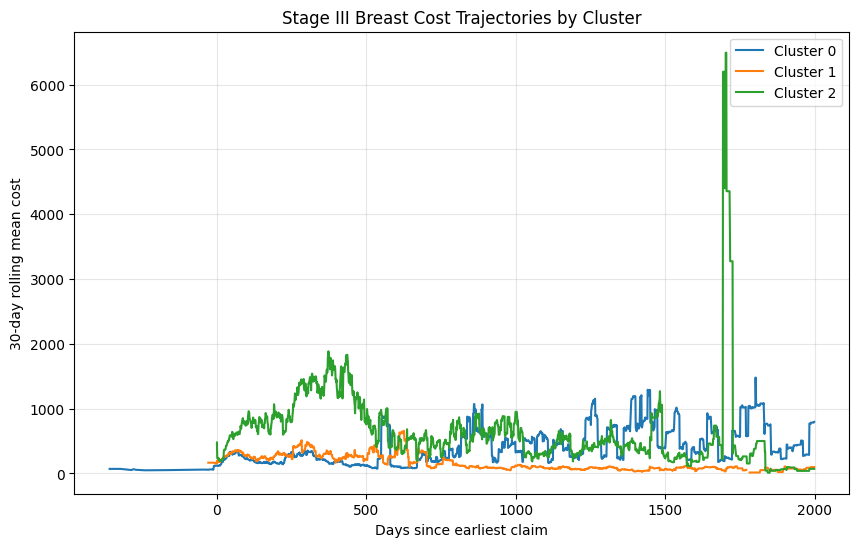

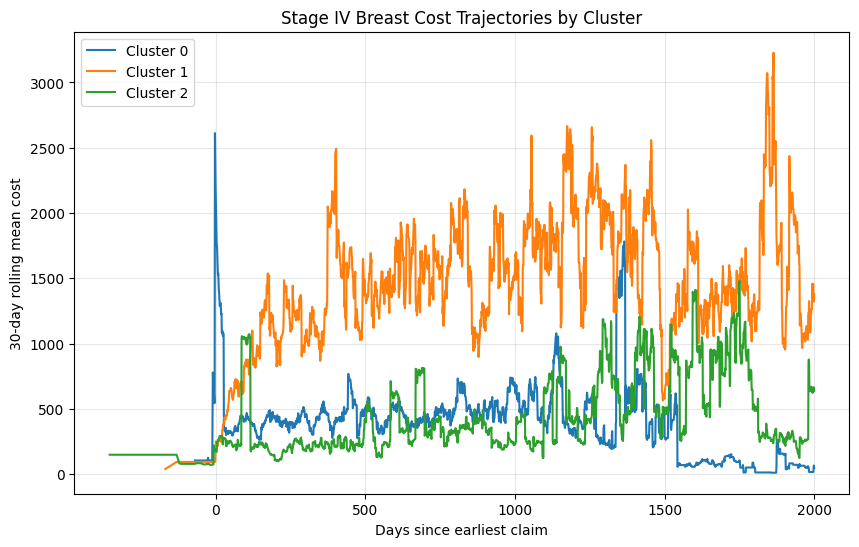

In [40]:
# Repeat the Stage II style clustering separately for Stage I, II, III, and IV.

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def safe_mean(x):
    if len(x) == 0:
        return 0
    return x.mean()

def build_stage_patient_features(df_stage):
    rows = []

    for pid, g in df_stage.groupby("member_number"):
        g = g.sort_values("days_since_earliest_dt")

        initial = g[g["phase"] == "initial"]
        continuing = g[g["phase"] == "continuing"]
        late = g[g["phase"] == "late"]

        rows.append({
            "member_number": pid,
            "stage": g["final_stage_simple"].iloc[0],
            "time_to_stage": g["most_recent_stage_date"].iloc[0],
            "followup_days": g["days_since_earliest_dt"].max(),
            "n_claims": len(g),
            "total_cost": g["c_allowed"].sum(),
            "mean_initial": safe_mean(initial["c_allowed"]),
            "mean_continuing": safe_mean(continuing["c_allowed"]),
            "mean_late": safe_mean(late["c_allowed"]),
        })

    out = pd.DataFrame(rows).fillna(0)
    return out

stage_cluster_results = {}
stage_order = ["I", "II", "III", "IV"]

for stage in stage_order:
    stage_df = breast[breast["final_stage_simple"] == stage].copy()

    patient_stage = build_stage_patient_features(stage_df)

    features = [
        "time_to_stage",
        "followup_days",
        "n_claims",
        "mean_initial",
        "mean_continuing",
        "mean_late",
        "total_cost",
    ]

    X = patient_stage[features].copy()
    X_scaled = StandardScaler().fit_transform(X)

    km = KMeans(n_clusters=3, random_state=42, n_init=10)
    patient_stage["cluster"] = km.fit_predict(X_scaled)

    stage_df = stage_df.merge(
        patient_stage[["member_number", "cluster"]],
        on="member_number",
        how="left"
    )

    stage_cluster_results[stage] = {
        "patient_table": patient_stage,
        "claims_table": stage_df,
        "features": features,
    }

# %%
for stage in stage_order:
    print(f"\nStage {stage} cluster summary")

    patient_stage = stage_cluster_results[stage]["patient_table"]

    summary = (
        patient_stage.groupby("cluster")
        .agg(
            n_patients=("member_number", "nunique"),
            mean_time_to_stage=("time_to_stage", "mean"),
            mean_followup=("followup_days", "mean"),
            mean_n_claims=("n_claims", "mean"),
            mean_initial=("mean_initial", "mean"),
            mean_continuing=("mean_continuing", "mean"),
            mean_late=("mean_late", "mean"),
            mean_total_cost=("total_cost", "mean"),
            median_total_cost=("total_cost", "median"),
        )
        .round(2)
    )

    display(summary)

for stage in stage_order:
    claims_stage = stage_cluster_results[stage]["claims_table"]

    cluster_daily = (
        claims_stage.groupby(["days_since_earliest_dt", "cluster"])
        .agg(mean_cost=("c_allowed", "mean"))
        .reset_index()
    )

    pivot = cluster_daily.pivot(
        index="days_since_earliest_dt",
        columns="cluster",
        values="mean_cost"
    )

    pivot = pivot[pivot.index <= 2000]
    rolling = pivot.rolling(30, min_periods=1).mean()

    plt.figure(figsize=(10, 6))
    for c in rolling.columns:
        plt.plot(rolling.index, rolling[c], label=f"Cluster {c}")

    plt.title(f"Stage {stage} Breast Cost Trajectories by Cluster")
    plt.xlabel("Days since earliest claim")
    plt.ylabel("30-day rolling mean cost")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

- Each stage still splits into multiple cost pathways, even after holding stage fixed, so patients within the same stage do not all follow the same spending pattern.
- Across stages, one cluster usually looks like lower-cost / shorter-follow-up, one looks like higher-intensity / higher-cost, and one looks like longer-follow-up or persistent care.
- The highest-cost cluster becomes especially pronounced in Stages III–IV, where patients have much higher claim counts and much higher total cost.